# Commodity-Linked Stocks vs. S&P 500: Beta, Alpha & Risk-Adjusted Performance

**Research Question:** How do commodity-producing equities behave relative to the broader U.S. equity market?

**Universe:** Oil/Energy (XOM, COP), Metals/Mining (FCX, NEM), Agriculture (ADM)

**Market Proxy:** SPY

**Analysis:** Estimate each stock's market sensitivity and performance relative to SPY using beta, alpha, R^2, correlation, annualized volatility, and Sharpe ratio. Compare how these relationships differ across commodity sectors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

RISK_FREE_ANNUAL = 0.04
rf_daily = RISK_FREE_ANNUAL / 252

## 1. Data collection
Download daily prices for the commodity-linked stocks plus the SPY benchmark.

1)Data from 2021 to 2025

2)Data from 2016 to 2020

Question: did the market exposure and risk-adjusted performance of commodity-linked equities change after 2020?

In [2]:
TICKERS = ["XOM", "COP", "FCX", "NEM", "ADM"]
BENCHMARK = "SPY"

data_2021_2025 = yf.download(
    TICKERS + [BENCHMARK],
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data_2016_2020 = yf.download(
    TICKERS + [BENCHMARK],
    start="2016-01-01",
    end="2021-01-01",
    auto_adjust=True

)

prices_2021_2025 = data_2021_2025["Close"]
prices_2016_2020 = data_2016_2020["Close"]

returns_2021_2025 = prices_2021_2025.pct_change().dropna()
returns_2016_2020 = prices_2016_2020.pct_change().dropna()

[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed


## 2. Individual stock statistics
Average daily return, annualized arithmetic return, geometric return and annualized volatility for each equity.

In [3]:
def period_stats(returns):
    return pd.DataFrame({
        "avg_daily_return_%":      returns.mean() * 100,
        "annualized_arithmetic_return_%":     returns.mean() * 252 * 100,
        "annualized_geometric_return_%":      ((1 + returns).prod() ** (252 / len(returns)) - 1) * 100,
        "annualized_volatility_%": returns.std() * np.sqrt(252) * 100,
    }).loc[TICKERS + [BENCHMARK]]

stats_2016_2020 = period_stats(returns_2016_2020)
stats_2021_2025 = period_stats(returns_2021_2025)

print("2016–2020")
display(stats_2016_2020)

print("2021–2025")
display(stats_2021_2025)

2016–2020


,avg_daily_return_%,annualized_arithmetic_return_%,annualized_geometric_return_%,annualized_volatility_%
Ticker,,,,
XOM,-0.0151,-3.7986,-7.5992,28.6553
COP,0.0345,8.6838,-0.6418,43.1124
FCX,0.1793,45.1843,32.6563,58.2449
NEM,0.1256,31.6614,28.7770,35.7001
ADM,0.0539,13.5727,10.5363,26.6093
SPY,0.0641,16.1589,15.4480,18.8612


2021–2025


,avg_daily_return_%,annualized_arithmetic_return_%,annualized_geometric_return_%,annualized_volatility_%
Ticker,,,,
XOM,0.1155,29.1140,28.9797,27.0234
COP,0.1053,26.5377,23.2712,33.4586
FCX,0.0962,24.2497,14.9408,45.4401
NEM,0.0742,18.6911,13.1781,35.4550
ADM,0.0382,9.6309,5.8204,27.7271
SPY,0.0603,15.1994,14.7240,17.1110


## 3. CAPM Regression via Statsmodels

For each stock, regress its daily excess return on SPY's daily excess return:

$$
r_{stock,t} - r_f
=
\alpha + \beta(r_{SPY,t} - r_f) + \varepsilon_t
$$

`statsmodels` estimates beta, alpha, R², and the statistical significance
(p-values) of each coefficient.

In [4]:
def market_regression(returns):
    regression_rows = []
    X = sm.add_constant(returns[BENCHMARK] - rf_daily)

    for ticker in TICKERS:
        model = sm.OLS(returns[ticker] - rf_daily, X).fit()
        regression_rows.append({
            "ticker": ticker,
            "beta": model.params[BENCHMARK],
            "alpha_annualized_%": model.params["const"] * 252 * 100,
            "r_squared": model.rsquared,
            "beta_p_value": model.pvalues[BENCHMARK],
            "alpha_p_value": model.pvalues["const"],
        })
    return pd.DataFrame(regression_rows).set_index("ticker")


regression_2016_2020 = market_regression(returns_2016_2020)
regression_2021_2025 = market_regression(returns_2021_2025)

print("2016–2020")
display(regression_2016_2020)

print("2021–2025")
display(regression_2021_2025)


2016–2020


,beta,alpha_annualized_%,r_squared,beta_p_value,alpha_p_value
ticker,,,,,
XOM,1.0349,-20.3817,0.4640,0.0000,0.0303
COP,1.4154,-12.5264,0.3835,0.0000,0.4091
FCX,1.7334,20.1078,0.3151,0.0000,0.3521
NEM,0.2964,24.0577,0.0245,0.0000,0.1281
ADM,0.9497,-1.9742,0.4531,0.0000,0.8229


2021–2025


,beta,alpha_annualized_%,r_squared,beta_p_value,alpha_p_value
ticker,,,,,
XOM,0.5409,19.0568,0.1173,0.0000,0.0947
COP,0.7547,14.0850,0.1490,0.0000,0.3095
FCX,1.4755,3.7255,0.3087,0.0000,0.8261
NEM,0.4960,9.1363,0.0573,0.0000,0.5544
ADM,0.5217,-0.2114,0.1036,0.0000,0.9857


### Interpretation for 2016–2020
- **FCX had the highest beta (1.7334)**, making it the most sensitive to movements in SPY. A 1% change in SPY was associated with about a 1.73% change in FCX on average. Copper is a commodity whose demand tracks global growth, so it shares a driver with the equity market.

- **COP also had a beta above 1 (1.4154)**, while XOM was close to 1 (1.0349). This suggests energy and copper-related equities were relatively sensitive to broad equity-market movements during this period.

- **NEM had the lowest beta (0.2964)** and the lowest R² (0.0245). Only about 2.5% of NEM's daily return variation was explained by SPY, suggesting that broader market movements played a relatively small role in explaining its returns. This is consistent with gold's primary drivers, which include real interest rates, the U.S. dollar, and inflation.

- **XOM and ADM had relatively high R² values (0.4640 and 0.4531)**, meaning roughly 46% and 45% of their daily return variation was explained by SPY.

- All beta estimates are statistically significant based on their near-zero p-values.

- **XOM's alpha is statistically significant at the 5% level (p = 0.0303)** and is negative, while the alpha estimates for COP, FCX, NEM, and ADM are not statistically significant at the 5% level.


### Interpretation for 2021–2025
- **FCX had the highest beta (1.4755)**, making it the most sensitive to movements in SPY. A 1% change in SPY was associated with approximately a 1.48% change in FCX on average.

- **XOM, COP, NEM, and ADM all had betas below 1**, indicating lower sensitivity to broad market movements than the market itself. XOM, for example, had a beta of 0.5408.

- **FCX had the highest R² (0.3087)**, meaning approximately 30.9% of its daily return variation was explained by movements in SPY.

- **NEM had the lowest R² (0.0573)**, meaning SPY explained only about 5.7% of its daily return variation. This suggests that factors outside the broad equity market played a larger role in NEM's returns.

- All beta estimates were statistically significant, with p-values close to zero.

- None of the estimated alphas were statistically significant at the 5% level. XOM had the lowest alpha p-value at 0.0947, but this is still above 0.05.

### Comparison across periods
- Betas decreased, four of the five fell (XOM 1.03→0.54, COP 1.42→0.75, ADM 0.95→0.52, FCX 1.73→1.48). NEM was the exception, rising from 0.30 to 0.50, plausibly because real rates became a shared driver of both gold and equities during the 2021–2025 inflation and rate-hiking cycle.

- R² fell for XOM 0.46→0.12 and ADM 0.45→0.10. The market factor explains substantially less of these stocks in the later period, implying that commodity-specific drivers dominated.

- Alpha estimates are not stable. XOM's alpha was significantly negative in 2016–2020 (−20.4%, p = 0.030) and positive in 2021–2025 (+19.1%), though not significant. Rather than persistent skill or mispricing, this sign reversal is consistent with oil-price regime effects that a market-only model absorbs into the intercept.

- Taken together, the results suggest that a single historical beta is a poor input for hedging or position sizing in these names, since the relationship to the market is not stable across regimes.

## 4. Correlation with SPY

Correlation measures the strength and direction of the linear relationship between each stock's daily returns and SPY's daily returns.

In [5]:
def market_correlation(returns):
    return (
        returns[TICKERS]
        .corrwith(returns[BENCHMARK])
        .to_frame("correlation_with_SPY")
    )

correlation_2016_2020 = market_correlation(returns_2016_2020)
correlation_2021_2025 = market_correlation(returns_2021_2025)

print("2016–2020")
display(correlation_2016_2020)

print("2021–2025")
display(correlation_2021_2025)

2016–2020


,correlation_with_SPY
Ticker,
XOM,0.6812
COP,0.6192
FCX,0.5613
NEM,0.1566
ADM,0.6731


2021–2025


,correlation_with_SPY
Ticker,
XOM,0.3425
COP,0.3860
FCX,0.5556
NEM,0.2394
ADM,0.3219


## 5. Risk-Adjusted Performance: Sharpe Ratio

The Sharpe ratio measures excess return earned per unit of total volatility.

$$
\text{Sharpe Ratio}
=
\frac{R_p-R_f}{\sigma_p}
$$

In [6]:
def sharpe_ratio(returns):
    excess = returns - rf_daily
    return pd.DataFrame({
        "sharpe_ratio": excess.mean() / returns.std() * np.sqrt(252)
    }).loc[TICKERS + [BENCHMARK]]

sharpe_2016_2020 = sharpe_ratio(returns_2016_2020)
sharpe_2021_2025 = sharpe_ratio(returns_2021_2025)

print("2016-2020")
display(sharpe_2016_2020)

print("2021-2025")
display(sharpe_2021_2025)

2016-2020


,sharpe_ratio
Ticker,
XOM,-0.2722
COP,0.1086
FCX,0.7071
NEM,0.7748
ADM,0.3597
SPY,0.6447


2021-2025


,sharpe_ratio
Ticker,
XOM,0.9293
COP,0.6736
FCX,0.4456
NEM,0.4144
ADM,0.2031
SPY,0.6545


## Sharpe Interpretation

### 2016–2020

- **NEM had the highest Sharpe ratio (0.7748)**, followed closely by FCX (0.7071). Both exceeded SPY's 0.6446, meaning they delivered more excess return per unit of volatility than the market over this period.

- **XOM had a negative Sharpe ratio (−0.2722)**, indicating its return fell below the assumed risk-free rate. An investor would have done better holding T-bills.

- **COP (0.1086) and ADM (0.3597) were positive but well below SPY.** Both took on more volatility than the market without being compensated for it.

- Only two of five names beat the benchmark on a risk-adjusted basis.

### 2021–2025

- **XOM had the highest Sharpe ratio (0.9293)**, and was the only name to meaningfully exceed SPY's 0.6545.

- **COP (0.6736) was essentially level with the benchmark**, offering no risk-adjusted advantage despite a large raw return.

- **FCX (0.4456), NEM (0.4144), and ADM (0.2031) all underperformed SPY**, taking on materially more volatility for less risk-adjusted return.

- Again, only one or two of five names beat simply holding the index.

### Comparison

- Risk-adjusted leadership rotated completely. XOM went from the worst performer (−0.2722) to the best (0.9293); NEM and FCX moved the opposite direction.

- SPY's own Sharpe was nearly identical across periods (0.6446 vs. 0.6545), so the rotation reflects changes in the commodity names rather than a shift in the market benchmark.

- In both periods, most of these stocks did not beat the index on a risk-adjusted basis. Their appeal is diversification, which has lower coorelation with the market than superior risk-adjusted return.

*Note: A constant 4% annual risk-free rate is used for simplicity. Actual short-term rates were near zero for much of 2016–2021 and above 5% in 2023–2024, which affects comparability across periods.*

## 6. Summary Tables

Combine the primary return, risk, CAPM, correlation, and Sharpe ratio metrics for each period.

In [7]:
summary_2016_2020 = pd.concat(
    [
        stats_2016_2020[
            ["annualized_geometric_return_%", "annualized_volatility_%"]
        ],
        regression_2016_2020[
            ["beta", "alpha_annualized_%", "r_squared"]
        ],
        correlation_2016_2020,
        sharpe_2016_2020
    ],
    axis=1
)

summary_2021_2025 = pd.concat(
    [
        stats_2021_2025[
            ["annualized_geometric_return_%", "annualized_volatility_%"]
        ],
        regression_2021_2025[
            ["beta", "alpha_annualized_%", "r_squared"]
        ],
        correlation_2021_2025,
        sharpe_2021_2025
    ],
    axis=1
)

print("2016–2020")
display(summary_2016_2020)

print("2021–2025")
display(summary_2021_2025)

2016–2020


,annualized_geometric_return_%,annualized_volatility_%,beta,alpha_annualized_%,r_squared,correlation_with_SPY,sharpe_ratio
XOM,-7.5992,28.6553,1.0349,-20.3817,0.4640,0.6812,-0.2722
COP,-0.6418,43.1124,1.4154,-12.5264,0.3835,0.6192,0.1086
FCX,32.6563,58.2449,1.7334,20.1078,0.3151,0.5613,0.7071
NEM,28.7770,35.7001,0.2964,24.0577,0.0245,0.1566,0.7748
ADM,10.5363,26.6093,0.9497,-1.9742,0.4531,0.6731,0.3597
SPY,15.4480,18.8612,NaN,NaN,NaN,NaN,0.6447


2021–2025


,annualized_geometric_return_%,annualized_volatility_%,beta,alpha_annualized_%,r_squared,correlation_with_SPY,sharpe_ratio
XOM,28.9797,27.0234,0.5409,19.0568,0.1173,0.3425,0.9293
COP,23.2712,33.4586,0.7547,14.0850,0.1490,0.3860,0.6736
FCX,14.9408,45.4401,1.4755,3.7255,0.3087,0.5556,0.4456
NEM,13.1781,35.4550,0.4960,9.1363,0.0573,0.2394,0.4144
ADM,5.8204,27.7271,0.5217,-0.2114,0.1036,0.3219,0.2031
SPY,14.7240,17.1110,NaN,NaN,NaN,NaN,0.6545


## 7. Visualizations

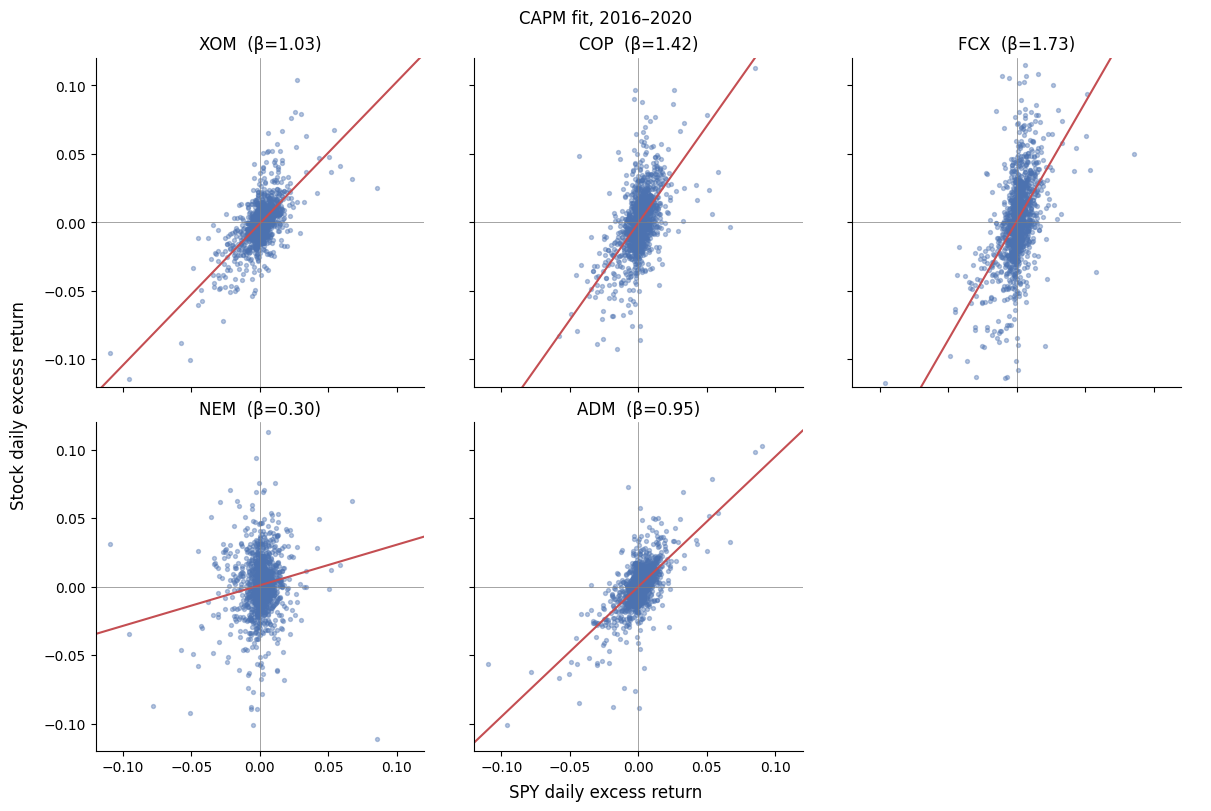

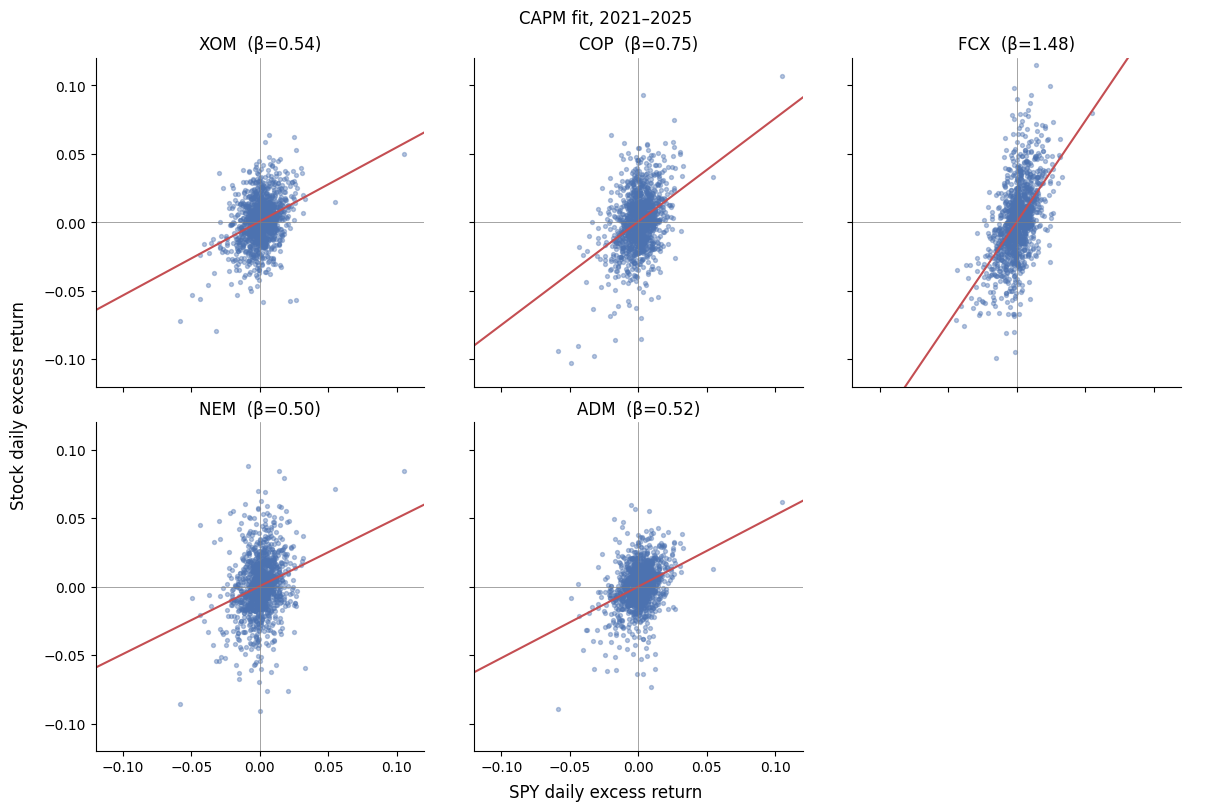

In [8]:
def scatter_grid(returns, regression_df, title):
    plot_tickers = [t for t in TICKERS if t != BENCHMARK]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True,
                             constrained_layout=True)
    axes = axes.flatten()
    lim = 0.12

    for i, ticker in enumerate(plot_tickers):
        ax = axes[i]
        x = returns[BENCHMARK] - rf_daily
        y = returns[ticker] - rf_daily
        beta = regression_df.loc[ticker, "beta"]
        alpha_daily = regression_df.loc[ticker, "alpha_annualized_%"] / 100 / 252

        grid = np.linspace(-lim, lim, 100)
        ax.scatter(x, y, s=8, alpha=0.4, color="#4C72B0")
        ax.plot(grid, alpha_daily + beta * grid, color="#C44E52", lw=1.5)
        ax.axhline(0, color="gray", lw=0.5)
        ax.axvline(0, color="gray", lw=0.5)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.set_title(f"{ticker}  (β={beta:.2f})")
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[len(plot_tickers):]:
        ax.axis("off")

    fig.supxlabel(f"{BENCHMARK} daily excess return")
    fig.supylabel("Stock daily excess return")
    fig.suptitle(title)
    return fig

scatter_grid(returns_2016_2020, regression_2016_2020, "CAPM fit, 2016–2020")
plt.show()
scatter_grid(returns_2021_2025, regression_2021_2025, "CAPM fit, 2021–2025")
plt.show()

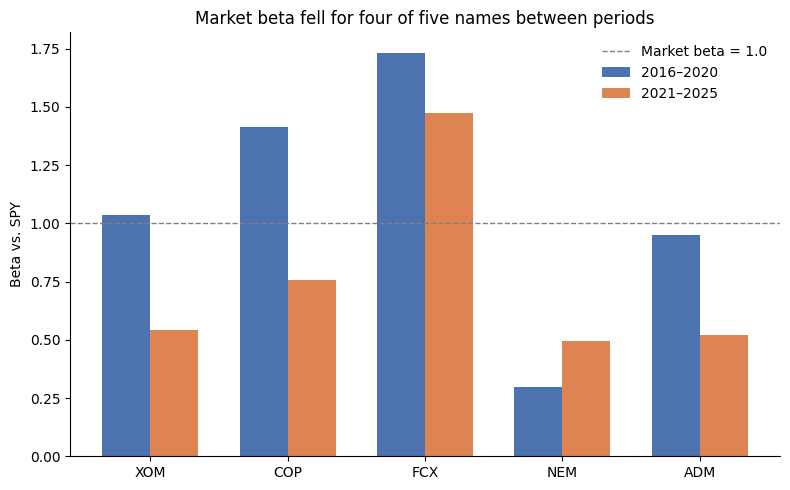

In [9]:
capm = pd.concat(
    {"2016-2020": regression_2016_2020,
     "2021-2025": regression_2021_2025},
    axis=1,
)

b = capm.xs("beta", axis=1, level=1)
x = np.arange(len(b))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, b["2016-2020"], w, label="2016–2020", color="#4C72B0")
ax.bar(x + w/2, b["2021-2025"], w, label="2021–2025", color="#DD8452")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="Market beta = 1.0")

ax.set_xticks(x, b.index)
ax.set_ylabel("Beta vs. SPY")
ax.set_title("Market beta fell for four of five names between periods")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

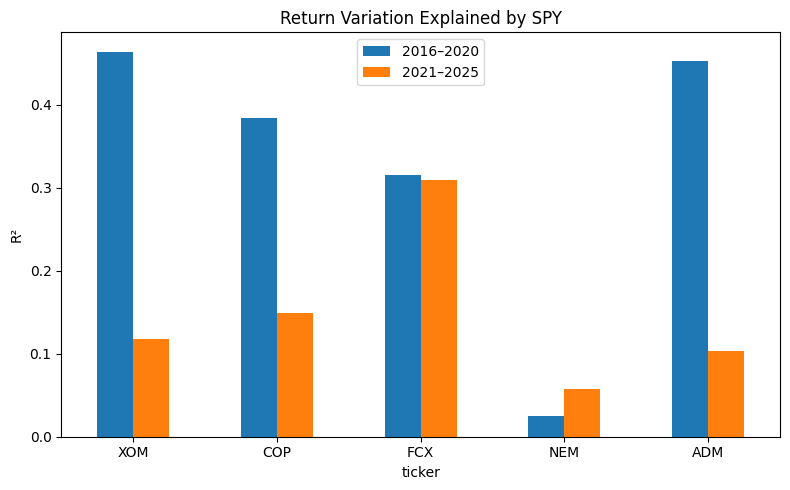

In [10]:
r2_comparison = pd.DataFrame({
    "2016–2020": regression_2016_2020["r_squared"],
    "2021–2025": regression_2021_2025["r_squared"]
})

r2_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("R²")
plt.title("Return Variation Explained by SPY")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


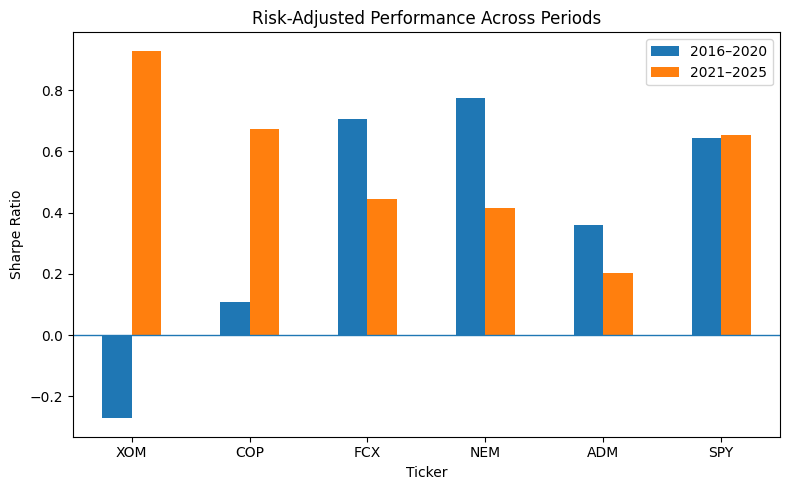

In [11]:
sharpe_comparison = pd.DataFrame({
    "2016–2020": sharpe_2016_2020["sharpe_ratio"],
    "2021–2025": sharpe_2021_2025["sharpe_ratio"]
})

sharpe_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.axhline(0, linewidth=1)
plt.ylabel("Sharpe Ratio")
plt.title("Risk-Adjusted Performance Across Periods")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Key Findings

The analysis shows meaningful differences in how commodity-linked equities behaved in relation to the broader market index across the two periods.

- **Betas compressed toward the market.** 4 out of the 5 names saw beta fall between
  periods: XOM 1.03→0.54, COP 1.42→0.75, ADM 0.95→0.52, and FCX 1.73→1.48. NEM was the exception, rising from 0.30 to 0.50, possibly due to changes in real interest rates, which spiked post COVID-19.

- **FCX was the most market-sensitive name in both periods.** Copper is an industrial input whose demand tracks global growth, so it shares a driver with the equity market. Operating leverage at the miner amplifies that: with largely fixed extraction costs, a given move in the copper price produces a larger move in profit.

- **The market factor lost explanatory power.** R² fell sharply for the names where it had been highest (XOM 0.464→0.117 and ADM 0.453→0.104), which implies that commodity-specific drivers dominated in the later period.

- **NEM was weakly related to SPY throughout**, with R² of 0.025 and 0.057. This is consistent with gold's primary drivers, real rates, the dollar, and crisis demand, being largely distinct from those of the broad equity market.

- **Alpha estimates were not stable across periods.** XOM's alpha was significantly negative in 2016–2020 (−20.4%, p = 0.030) and positive in 2021–2025 (+19.1%, p = 0.095, not significant). Rather than indicating persistent skill or mispricing, this sign reversal is consistent with oil-price regime effects that a market-only model absorbs into the intercept. Across ten regressions at the 5% level, roughly one false positive would be expected by chance.

- **Most of these names did not beat the index on a risk-adjusted basis.** In 2016–2020 only NEM (0.775) and FCX (0.707) exceeded SPY's 0.645; in 2021–2025 only XOM (0.929) meaningfully exceeded SPY's 0.655. SPY's own Sharpe was nearly identical across periods, so the rotation among the commodity names reflects changes in those stocks rather than in the benchmark.

Overall, commodity-linked equities do not behave as a homogeneous asset class. Their sensitivity to broad market risk differs across firms and changes considerably over time, which implies that **a single historical beta is a poor input for hedging or position sizing in these names.** Their portfolio appeal lies in low correlation with the market rather than in superior risk-adjusted returns.

## 9. Limitations and Extensions

- SPY is the only market factor included in the CAPM regression.
- Commodity-linked equities are companies rather than direct commodity exposures.
- Failed to account for COVID-19 and post COVID-19 era, which influenced U.S. economy greatly. Some of the difference in R² between periods may reflect that episode rather than a structural change. A robustness check excluding 2020 would separate the two.
- A constant 4% annual risk-free rate is used for simplicity.
- Results depend on the selected sample periods.
- A future extension could include oil, gold, and copper returns to separate broad market exposure from underlying commodity-price exposure.